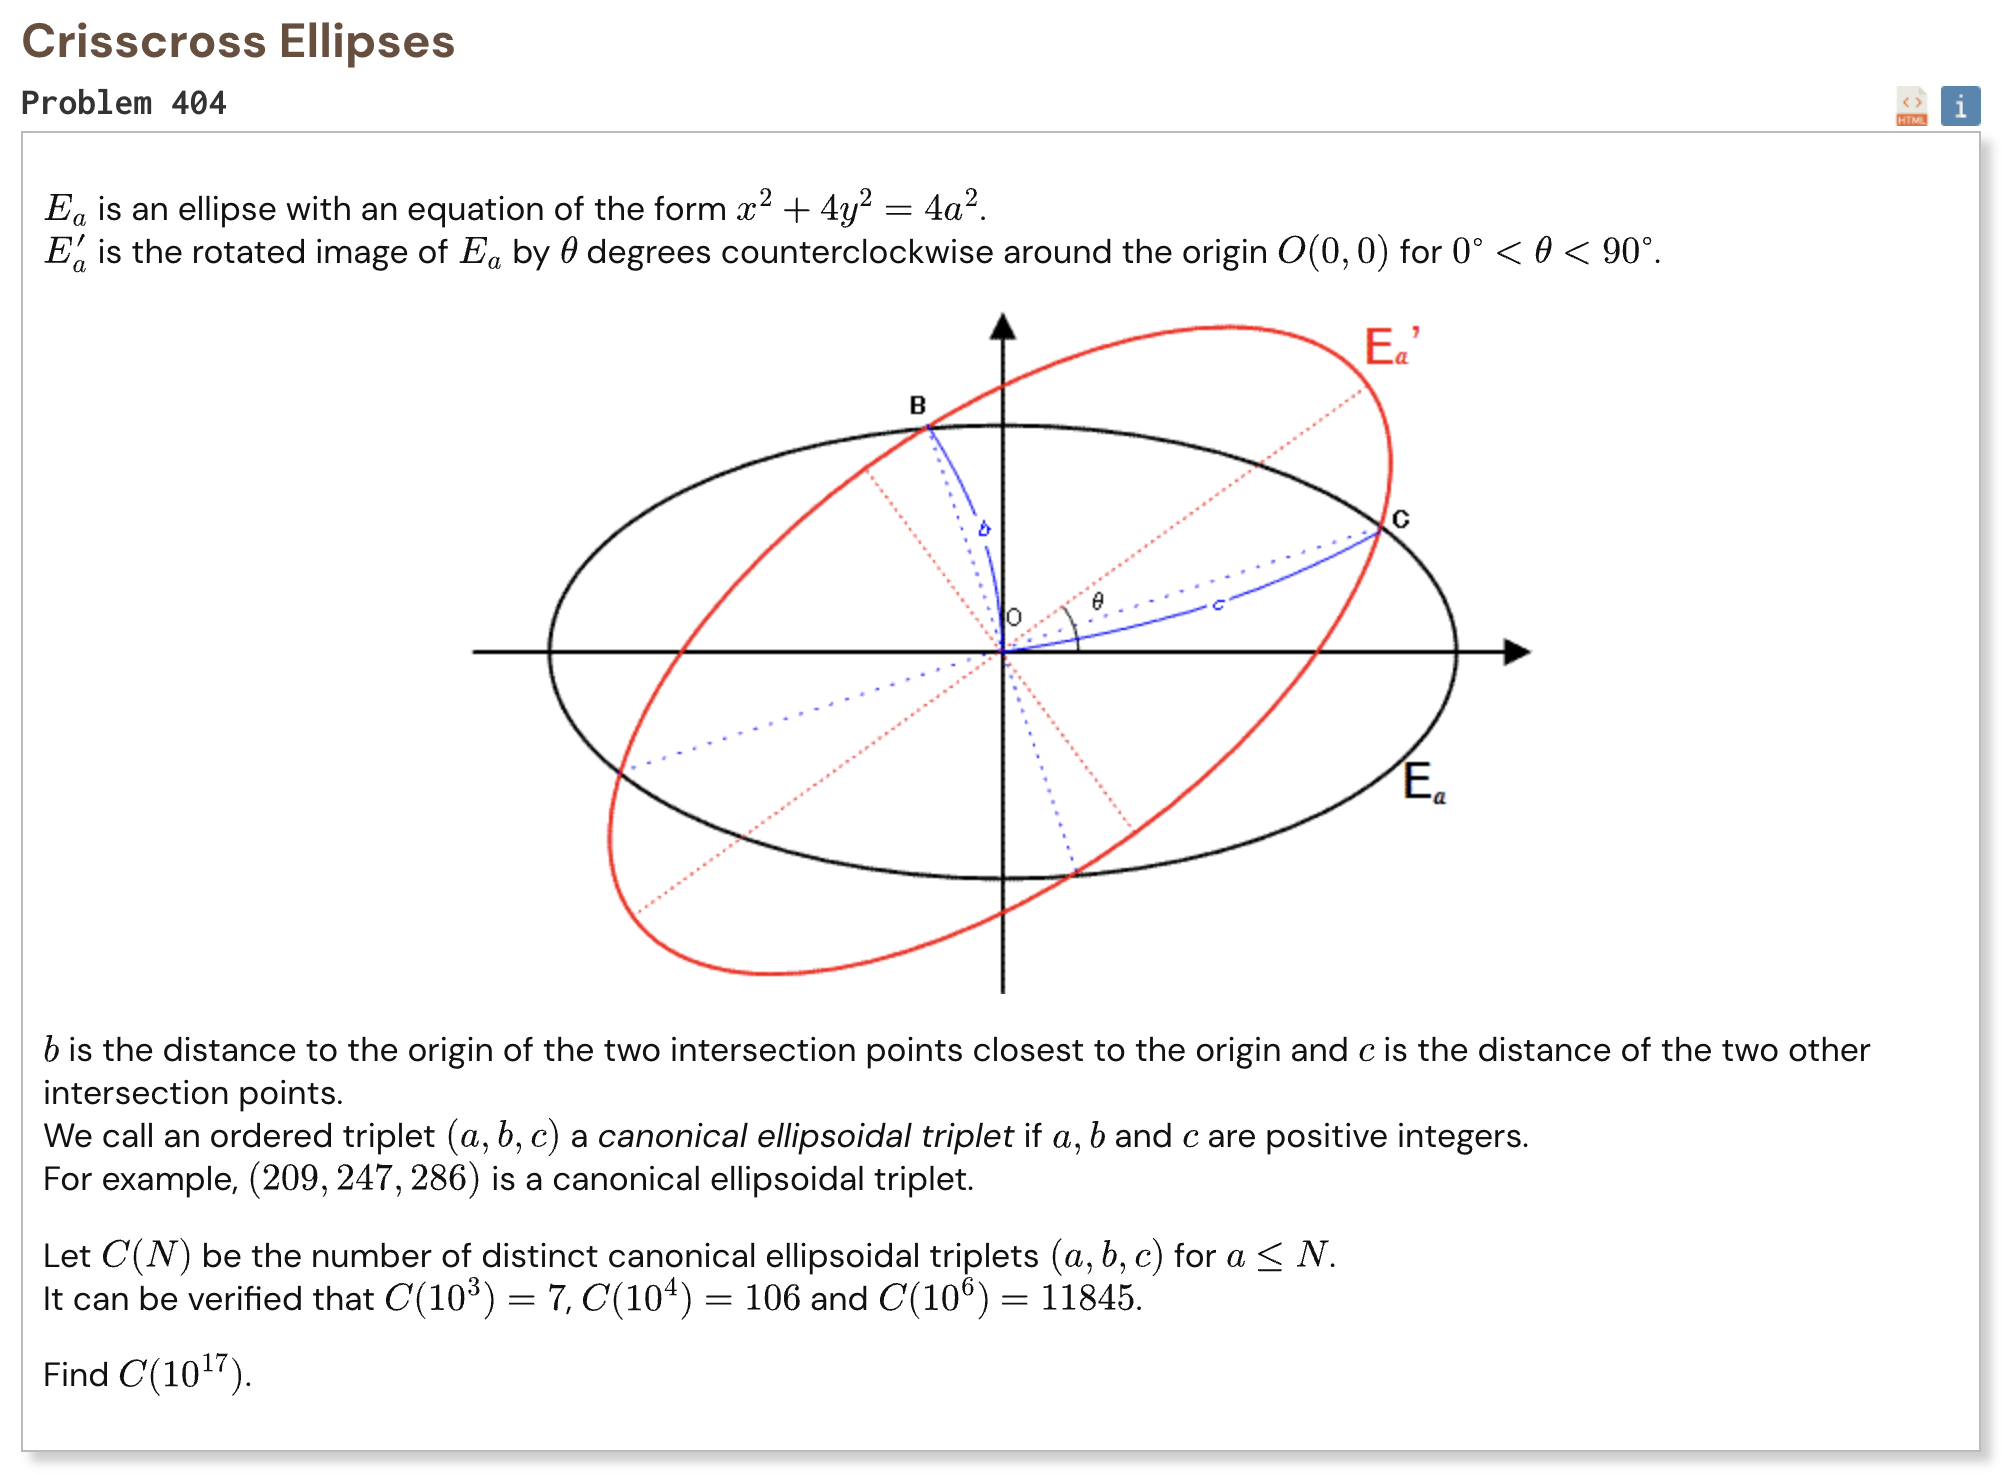

## Initial approach

* turn the ellipse intersection condition into an integer triangle problem
* generate the basic solutions using two smaller coprime numbers
* check two possible ranges because both produce valid triangle shapes
* skip pairs with the wrong parity or divisibility
* find the smallest ellipse size produced by each basic solution
* count every scaled copy that remains within the limit
* add these counts to get the final number of triplets

In [1]:
from math import gcd, isqrt

def count_triplets(limit):
    m_limit = isqrt(isqrt(2 * limit)) + 1
    total = 0

    for m in range(1, m_limit + 1):
        m_squared = m * m

        start = -(m // 3)
        if m % 3 == 0:
            start += 1

        for n in range(start, 0):
            if m % 2 == 1 and n % 2 == 1:
                continue
            if (m - 2 * n) % 5 == 0:
                continue
            if gcd(m, -n) != 1:
                continue

            n_squared = n * n
            product = m * n

            first = m_squared - n_squared - 4 * product
            second = m_squared - n_squared + product
            smallest_a = first * second

            if smallest_a <= limit:
                total += limit // smallest_a

        for n in range(m // 2 + 1, m):
            if m % 2 == 1 and n % 2 == 1:
                continue
            if (m - 2 * n) % 5 == 0:
                continue
            if gcd(m, n) != 1:
                continue

            n_squared = n * n
            product = m * n

            first = n_squared + 4 * product - m_squared
            second = m_squared - n_squared + product
            smallest_a = first * second

            if smallest_a <= limit:
                total += limit // smallest_a

    return total

In [2]:
%%time
result = count_triplets(10**17)
print("Result:", result)

Result: 1199215615081353
CPU times: user 42.6 s, sys: 306 ms, total: 42.9 s
Wall time: 43 s
